In [15]:
import sys
if "tf_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import torch


环境配置正常


In [16]:
def tensor_print(t , num=0):
    print(f"{t} , type:{type(t)}" , end='')
    try:
        print(f' row:{t.shape[0]} , columns:{t.shape[1]} , last:{t.shape[-1]}')
    except Exception as e:
        print('t.shape:',t.shape)        
    if num != 0:
        print('-' * 15,end='')
        print(f' 第{num}项如上',end='')
        print('-' * 15)
    else:
        print('-'*30)

<font color = #000000 >

## 1-1 自动微分模块

+ 只有标量张量才能求导求梯度!
</font>

<font color = #000000 >

## 1-1 自动微分模块

+ 只有标量张量才能求导求梯度!
</font>

In [17]:
# 例1: 更新一次参数

# 1. 定义变量,记录初始权重w(旧)
w = torch.tensor(10 , requires_grad=True , dtype=torch.float)   # 标量张量才能求导求梯度!

# 2. 定义loss变量,表示损失函数
loss = 2 * w ** 2    # loss = 2w^2 -> 求导 4w

# 3. 计算梯度 , 完成后会记录到 w.grad 属性中
loss.sum().backward()   # sum保证是标量求导

# 4. 代入权重更新公式 w新 = w旧 - 学习率 * 梯度 , 更新权重
if w.grad is not None:
    w.data = w.data - 0.01 * w.grad # w.data参与计算而不是w,可以直接修改权重数值,不会计入记录值,速度更快

# 5. 打印结果
print(f'更新后的权重:{w}')

更新后的权重:9.600000381469727


In [18]:
# 例2: 自动微分模块案例:循环实现,计算梯度,更新参数

# 1. 定义变量,记录初始权重w(旧)
w = torch.tensor(10 , requires_grad=True , dtype=torch.float)

# 2. 定义loss变量,表示损失函数
loss = w ** 2 + 20    # loss 求导 2w

# 3. 迭代循环100遍
print(f'开始 权重初始值: {w} , (0.01 * w.grad) : 无 , loss:{loss}')

for i in range(1,101):
    # 3-1 正向计算(向前传播),迭代100次
    loss = w ** 2 + 20

    # 3-2 梯度清零(因为梯度默认为累加)
    if w.grad is not None:  # 第一次没有计算梯度,需要进行非空判断
        w.grad.zero_()
    
    # 3-3 反向传播
    loss.sum().backward() 

    # 3-4 梯度更新(w)
    if w.grad is not None:
        w.data = w.data - 0.01 * w.grad 
    
    # 3-5 打印本次梯度更新后的权重参数结果
    print(f'第{i}次,权重:{w} , 权重初始值:{0.01 * w.grad:.5f} , loss:{loss}')

# 4. 打印最终结果
print(f'最终结果 权重:{w} , 梯度:{w.grad} , loss:{loss}')


开始 权重初始值: 10.0 , (0.01 * w.grad) : 无 , loss:120.0
第1次,权重:9.800000190734863 , 权重初始值:0.20000 , loss:120.0
第2次,权重:9.604000091552734 , 权重初始值:0.19600 , loss:116.04000091552734
第3次,权重:9.411920547485352 , 权重初始值:0.19208 , loss:112.23681640625
第4次,权重:9.223682403564453 , 权重初始值:0.18824 , loss:108.5842514038086
第5次,权重:9.03920841217041 , 权重初始值:0.18447 , loss:105.0763168334961
第6次,权重:8.858424186706543 , 权重初始值:0.18078 , loss:101.70729064941406
第7次,权重:8.681255340576172 , 权重初始值:0.17717 , loss:98.4716796875
第8次,权重:8.507630348205566 , 权重初始值:0.17363 , loss:95.36419677734375
第9次,权重:8.337477684020996 , 权重初始值:0.17015 , loss:92.37977600097656
第10次,权重:8.170727729797363 , 权重初始值:0.16675 , loss:89.51353454589844
第11次,权重:8.007312774658203 , 权重初始值:0.16341 , loss:86.76078796386719
第12次,权重:7.847166538238525 , 权重初始值:0.16015 , loss:84.11705780029297
第13次,权重:7.690223217010498 , 权重初始值:0.15694 , loss:81.57801818847656
第14次,权重:7.536418914794922 , 权重初始值:0.15380 , loss:79.13953399658203
第15次,权重:7.385690689086914 , 权重初始值:0.15

<font color = #000000 >

## 1-2 自动微分-detach()

+ 先前的一般微分问题:一个张量一旦设置了自动微分,那么就不能转为np对象,所以需要detach
+ detach共享同一块空间,除非copy

</font>

In [19]:
# 定义张量
t1 = torch.tensor( [10,20] , requires_grad=True ,dtype=torch.float)
tensor_print(t1)
# 尝试改为np格式
try:
    n1 = t1.numpy()
except Exception as e:  
    print("张量转np错误,原因:",e)

# 解决方法
t2 = t1.detach()    # detach是共享空间的
tensor_print(t2)
print(type(t2))
print(t2.requires_grad) # t2不能自动微分,但是可以转为np了

# 最终解决方案
n2 = t1.detach().numpy()
print(type(n2))

tensor([10., 20.], requires_grad=True) , type:<class 'torch.Tensor'>t.shape: torch.Size([2])
------------------------------
张量转np错误,原因: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.
tensor([10., 20.]) , type:<class 'torch.Tensor'>t.shape: torch.Size([2])
------------------------------
<class 'torch.Tensor'>
False
<class 'numpy.ndarray'>


<font color = #000000 >

## 1-3 自动微分-完整应用
+ 切记设置tensor时需要`requires_grad=True`


</font>

In [20]:
torch.manual_seed(24)
# 1. 定义x,表示特征(输入数据)
x = torch.ones(2,5) # 2x5
tensor_print(x,1)

# 2. 定义y,表示真实值
y = torch.zeros(2,3) # 2x3
tensor_print(y,2)

# 3. 初始化可自动微分的权重和偏置
w = torch.randn(5,3 , requires_grad=True)  # z = x @ w + b
tensor_print(w,3)

b = torch.randn(3 , requires_grad=True)  # z = x @ w + b
tensor_print(b,4)
# 4. 向前正向传播得到预测值z
# z = x @ w + b
z = x @ w + b

# 5. 定义损失函数
criterion = torch.nn.MSELoss()  # 定义损失函数,这里其实就是使用一个函数接收torch的函数,没有运算,真正的运算在loss = criterion(z,y)
loss = criterion(z,y)   # loss = 损失结果(z为预测值,y为真实值)

# 6. 进行自动微分,求导,结合反向传播更新权重
loss.backward()

# 7. 打印更新后的结果
print(f'w的梯度:{w.grad}')
print(f'b的梯度:{b.grad}')

# 8. 后续:更新w : w新 = w旧 - 学习率 * 梯度


tensor([[1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1.]]) , type:<class 'torch.Tensor'> row:2 , columns:5 , last:5
--------------- 第1项如上---------------
tensor([[0., 0., 0.],
        [0., 0., 0.]]) , type:<class 'torch.Tensor'> row:2 , columns:3 , last:3
--------------- 第2项如上---------------
tensor([[ 1.0139,  0.8988, -0.2111],
        [-1.5326, -0.6163,  0.2288],
        [-0.1120, -2.0506, -0.6189],
        [-0.7804, -0.9217,  0.4807],
        [-0.7770,  0.8658,  0.7492]], requires_grad=True) , type:<class 'torch.Tensor'> row:5 , columns:3 , last:3
--------------- 第3项如上---------------
tensor([-0.8138,  0.6658, -0.8064], requires_grad=True) , type:<class 'torch.Tensor'>t.shape: torch.Size([3])
--------------- 第4项如上---------------
w的梯度:tensor([[-2.0013, -0.7721, -0.1184],
        [-2.0013, -0.7721, -0.1184],
        [-2.0013, -0.7721, -0.1184],
        [-2.0013, -0.7721, -0.1184],
        [-2.0013, -0.7721, -0.1184]])
b的梯度:tensor([-2.0013, -0.7721, -0.1184])


<font color = #000000 >

## 1-4 pytorch模拟线性回归
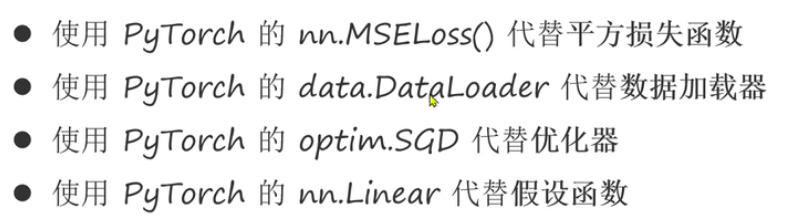

+ `数据集流程: numpy对象->张量Tensor->数据集对象TensorDataset->数据加载器DataLoader`

+ 关键训练部分

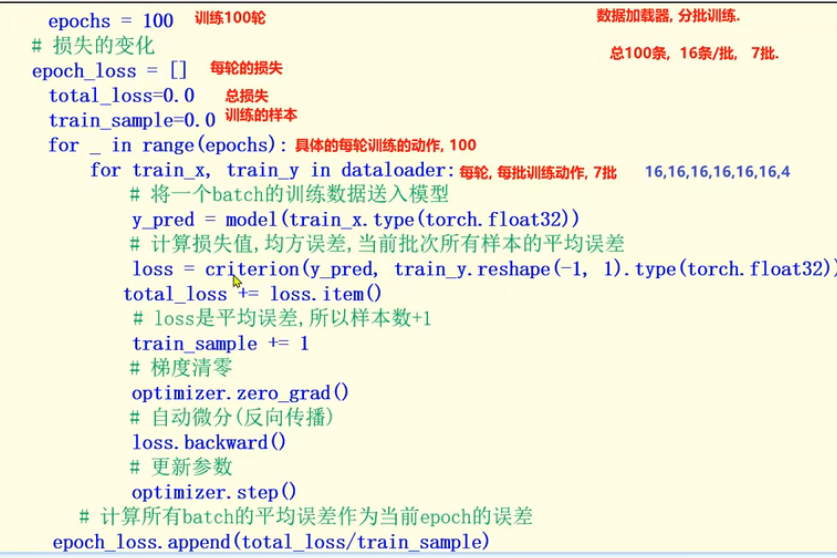
</font>

In [21]:
# 导包
import torch
from torch.utils.data import TensorDataset      # 构建数据集对象
from torch.utils.data import DataLoader         # 数据加载器
from torch import nn                            # nn里面有平方损失函数和假设函数
from torch import optim                         # optim模块中有优化器函数
from sklearn.datasets import make_regression    # 创建线性回归模型数据

In [22]:
# 1. 构建数据集
# 数据集流程: numpy对象->张量Tensor->数据集对象TensorDataset->数据加载器DataLoader
def create_data():
    # 1-1 创建数据集对象
    x,y,coef = make_regression(
        n_samples=100,  # 样本数据量
        n_features=1,   # 特征个数(也就是w个数)
        noise=10,       # 噪声
        bias=14.5,      # 偏置(b)
        coef=True,      # 是否返回真实权重
        random_state=3  # 随机种子号
    )

    # 1-2 封装为张量对象: numpy对象->张量Tensor
    x = torch.tensor(x , dtype=torch.float32)
    y = torch.tensor(y , dtype=torch.float32)

    # 1-3 返回结果
    return x,y,coef


In [23]:
# 2. 定义函数,表示模型训练
def train(x,y,coef):
    # 1. 创建数据集对象,把tensor -> 数据集对象 -> 数据加载器
    dataset = TensorDataset(x,y)    # 数据集对象

    # 2. 创建数据加载器对象:
    # dataset: 数据集对象 batch_size: 每轮的批次 shuffle: 是否打乱数据(训练集打乱,测试集不打乱)
    dataloader = DataLoader(dataset , batch_size=16 , shuffle=True)

    # 3. 创建初始的线性回归模型 
    # in_features: 输入特征维度  out_features: 输出特征维度 
    model = nn.Linear(in_features=1 , out_features=1)  
    
    # 4. 创建损失函数对象
    criterion = nn.MSELoss()

    # 5. 创建优化器对象
    optimizer = optim.SGD(model.parameters() , lr=0.01)

    # 6. 具体的训练过程
    # 6-1 定义变量: 训练轮数 每轮的平均损失值 训练总损失值 训练的样本数
    epochs, loss_list, total_loss, total_sample = 100 , [] , 0.0 , 0
    # 6-2 开始训练,按轮训练
    for epoch in range(epochs):
        # 6-3 每轮是分批次训练的, 所以从数据加载器中获得批次数据
        for trian_x , trian_y in dataloader:    # 每一轮都是7批次,16*6 + 4 , 加起来刚好是100,并且每次都会打乱
            # 6-4 模型预测
            y_pred = model(trian_x)
            # 6-5 计算每批的平均损失
            loss = criterion(y_pred , trian_y.reshape(-1,1))    # reshape成为n行1列
            # 6-6 计算总损失和样本批次数
            total_loss += loss.item() # item是本批次损失(平均)
            total_sample += 1   # 批次数 += 1
            # 6-7 梯度清零 + 反向传播 + 梯度更新
            optimizer.zero_grad()   # 梯度清零
            loss.sum().backward()   # 反向传播
            optimizer.step()        # 梯度更新
        # 6-8 本轮的平均损失添加到列表
        loss_list.append(total_loss / total_sample)
        print(f'轮数:{epoch+1}, 平均损失:{total_loss / total_sample}')
    # 7. 打印最终的训练结果
    print(f"{epochs}轮的平均损失分别为:{loss_list}")
    print(f"模型参数,权重: {model.weight} , 偏置: {model.bias}")

    # 8. 绘制损失曲线
    plt.plot(range(epochs) , loss_list)
    plt.title("损失值曲线变化图")
    plt.grid()  # 绘制网格线
    plt.show()

    # 9-1 样本点的分布情况
    plt.scatter(x,y)
    # 9-2 绘制预测值和真实值的关系
    # x:100个样本点的特征
    y_pred = torch.tensor(data=[v * model.weight + model.bias for v in x])
    y_true = torch.tensor(data=[v * coef + 14.5 for v in x])
    plt.plot(x , y_pred , color='red'   ,label='预测值')
    plt.plot(x , y_true , color='green' ,label='真实值')
    plt.legend()    # 图例
    plt.grid()      # 绘制网格线
    plt.show()


轮数:1, 平均损失:887.5926077706473
轮数:2, 平均损失:765.7410665239606
轮数:3, 平均损失:690.2034036545526
轮数:4, 平均损失:629.322469166347
轮数:5, 平均损失:569.3332940237863
轮数:6, 平均损失:522.5398819333031
轮数:7, 平均损失:481.94435228620256
轮数:8, 平均损失:445.00152492523193
轮数:9, 平均损失:413.1991184779576
轮数:10, 平均损失:386.42601405552455
轮数:11, 平均损失:363.34446597408936
轮数:12, 平均损失:342.458004906064
轮数:13, 平均损失:324.0023977258703
轮数:14, 平均损失:307.3050033997516
轮数:15, 平均损失:292.90849040803454
轮数:16, 平均损失:280.5493916613715
轮数:17, 平均损失:270.04687097693693
轮数:18, 平均损失:259.91730564359636
轮数:19, 平均损失:250.77681079663728
轮数:20, 平均损失:242.5911384991237
轮数:21, 平均损失:234.84522705337628
轮数:22, 平均损失:227.79723579852612
轮数:23, 平均损失:221.2706429973152
轮数:24, 平均损失:215.29207557723635
轮数:25, 平均损失:209.75157602582658
轮数:26, 平均损失:204.68294199220426
轮数:27, 平均损失:199.99964409278184
轮数:28, 平均损失:195.62194251041024
轮数:29, 平均损失:191.60603132388863
轮数:30, 平均损失:187.84094974881125
轮数:31, 平均损失:184.15159332257812
轮数:32, 平均损失:180.68607841219222
轮数:33, 平均损失:177.44410274968004
轮

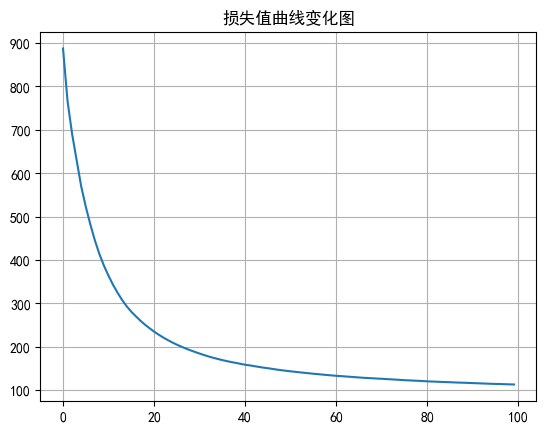

C:\Users\lxl\AppData\Local\Temp\ipykernel_1852\2221166854.py:56: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = torch.tensor(data=[v * coef + 14.5 for v in x])


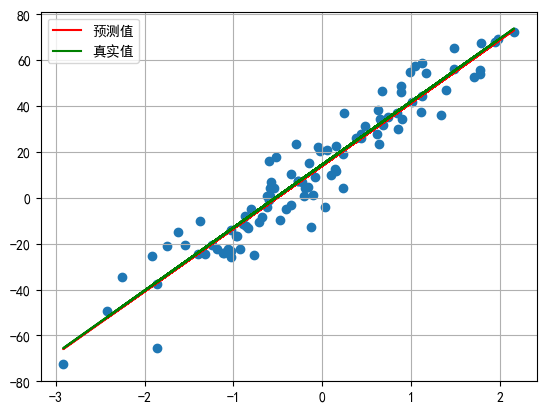

In [24]:
# 
x , y , coef = create_data()    # coef为w真,b=14.5,在函数里面定义了
train(x,y,coef)